<h3> Optimization </h3>

* $m$: mass
* $r_a$: arm radius
* $t_a$: arm thickness
* $l_s$: arm length
* $r_s$: strut radius
* $t_s$: strut thickness
* $d_s$: strut distance from center
* $\alpha$: Youngs Modulus / Shear Modulus
* $\sigma$: normal stress
* $\tau$: shear stress
* $\sigma_S$: normal strength
* $\tau_S$: shear strength
* $\sigma_{FOS}$: stress factor of safety 
* $\omega_p$: Propeller Forcing Function
* $\omega_1$: First normal mode
* $\omega_2$: Second normal mode
* $d_{max}$: Maximum displacement magnitude
* $d_a$: Maximum allowable displacement magnitude

$$ \[\min m(r_a,t_a,r_s,t_s,l_a,d_s)\] $$

subject to constraints:

$$ \ r_a > 0 \ t_a > 0 \ l_a \ge 1168.17\mathrm{mm} \ r_s > 0 \ t_s > 0 \ d_s > 0 $$

$$ \sigma_{FOS} (\frac{\tau}{\tau_S}^2 + \frac{\sigma}{\tau_S} \frac{2}{\alpha}) \le 1 $$
   
$$ \sigma_{FOS} (\frac{\sigma}{\sigma_S}^2 +  \frac{\alpha}{2} ^ 2 \frac{\tau}{\tau_S})  \le 1 $$

$$ \frac{\omega_1}{\omega_p} \le 1 $$

$$ \frac{\omega_p}{\omega_2} \le 1 $$

$$ \frac{d_{max}}{d_a} \le 1 $$




Stress NU Daniel (file:///C:/Users/natha/OneDrive/Documents/Daniel_YieldAndFailureCriteriaForCompositeMaterialsUnderStaticAndDynamicLoading_2015.pdf)



arm_length: 1127.3025260953375
Initial Guess:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[ 45   1  45   3 500]
energy | failure | nf upper | nf lower | deflection | mass
[0.11214665 0.2949555  3.04677532 0.2552959  0.38157609 0.01185807]
Mass (lbs) 26.142538623661526


Optimized:
arm radius | arm thickness | strut radius | strut thickness | deflection | strut dist from center
[4.5011280e+01 4.9978000e-01 4.4885650e+01 9.1939000e-01 4.9999127e+02]
energy | failure | nf upper | nf lower | deflection | mass
[0.10597105 0.59682858 3.04935619 0.23379215 1.00000017 0.00986214]
Mass (lbs) 21.742278837246882


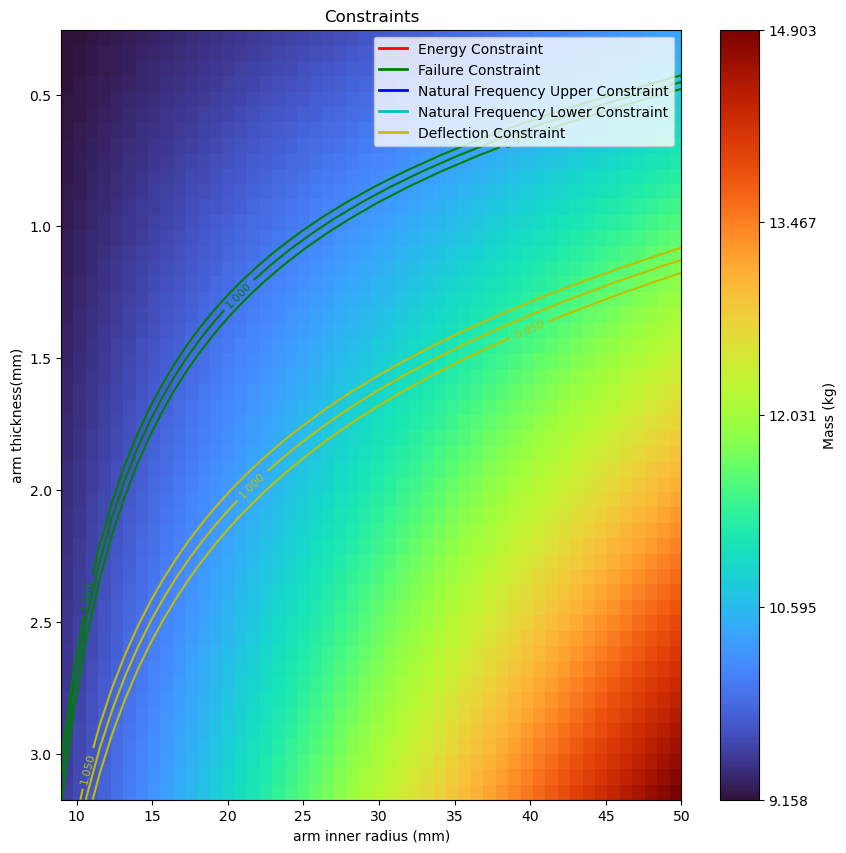

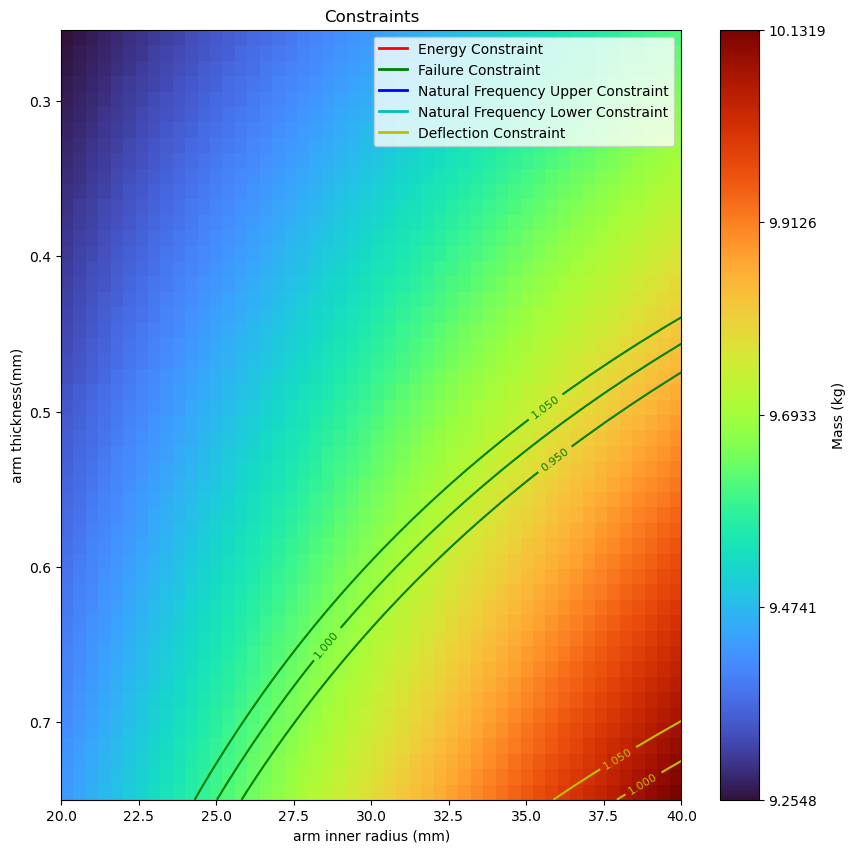

In [3]:
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
import Scripts.visualization as vis
from scipy.optimize import NonlinearConstraint
from matplotlib.lines import Line2D

drag_coeff = 0.256

# Battery geometry
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

# Mission profile generation
mission_profile = MissionProfile("m1", 1, 0, 0)
mission_profile.add_segment("takeoff",2,0,2,0,1)
mission_profile.add_segment("climb",15,550000,100000,300,0)
mission_profile.add_segment("cruise",50,2000000,110000,300,0)
mission_profile.add_segment("descent",10,2200000,50000,0,0)
mission_profile.add_segment("loiter",5,2200000,50000,0,0)
mission_profile.add_segment("land",10,2400000,0,0,0)

# Drone Power Analysis
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)

stress_FOS = 3
power_FOS = 1.25

allowable_deflection = 50.0 # mm

# https://store.tmotor.com/product/u8lite-l-kv95-u-efficiency.html
# Propeller Max RPM for 32in Propeller
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30

Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)
print("arm_length:", arm_length)

def Energy_Constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    drone_mass = DroneMass(drone_geometry)
    total_mass = drone_mass.total_mass + (45 * 10 ** -3)
    surface_area = drone_geometry.projected_surface_area

    d1_forces = DroneForces(total_mass, surface_area, drag_coeff, mission_profile)

    drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)
    drone_power.energy_consumption_calc(mission_profile.t_values, 2)
    drone_power.throttle_ratio_calc(16) # Power for max throttle in kw w/ full battery
    
    Energy_Constraint = ((drone_power.milliwatt_second_capacity - drone_power.energy_consumption[-1])/drone_power.milliwatt_second_capacity) *  power_FOS
    return Energy_Constraint


def Failure_Constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]
    
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()
    d1_fea.solve_failure()
    
    Failure_Constraint = d1_fea.beam_system.max_failure_crit * stress_FOS
    
    return Failure_Constraint


def Deflection_Constraint(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]

    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")
    
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.solve_static()
    
    max_disp = max(d1_fea.beam_system.mag_displacements)
    
    Deflection_Constraint =  max_disp / allowable_deflection
    
    return Deflection_Constraint
    
    
def Natural_Frequency_Upper_Constraint(x):
    arm_d1,arm_t, strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    drone_mass = DroneMass(drone_geometry)
    total_mass = drone_mass.total_mass + (45 * 10 ** -3)
    surface_area = drone_geometry.projected_surface_area

    d1_forces = DroneForces(total_mass, surface_area, drag_coeff, mission_profile)

    drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)
    drone_power.energy_consumption_calc(mission_profile.t_values, 2)
    drone_power.throttle_ratio_calc(16) # Power for max throttle in kw w/ full battery

    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    # d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Upper_Constraint = Propeller_Forcing_Function_Hz / Natural_Frequencies_Hz[1]
    
    return Natural_Frequency_Upper_Constraint


def Natural_Frequency_Lower_Constraint(x):
    arm_r1,arm_t,strut_r1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")


    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

    drone_mass = DroneMass(drone_geometry)
    total_mass = drone_mass.total_mass + (45 * 10 ** -3)
    surface_area = drone_geometry.projected_surface_area

    d1_forces = DroneForces(total_mass, surface_area, drag_coeff, mission_profile)

    drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)
    drone_power.energy_consumption_calc(mission_profile.t_values, 2)
    drone_power.throttle_ratio_calc(16) # Power for max throttle in kw w/ full battery

    # FEA
    d1_fea = DroneFEA(drone_geometry)
    d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
    d1_fea.create_drone_slice_beams() # arm beam | strut beam
    d1_fea.boundary_conditions_slice()
    # d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
    d1_fea.solve_fea()
    d1_fea.beam_system.solve_natural_frequencies()

    Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
    Natural_Frequency_Lower_Constraint = Natural_Frequencies_Hz[0] / Propeller_Forcing_Function_Hz

    return Natural_Frequency_Lower_Constraint


def Mass(x):
    arm_d1,arm_t,strut_d1,strut_t,strut_dist = [x[0],x[1],x[2],x[3],x[4]]
    # Beam properties
    # arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
    # strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
    arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
    strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")
    
    # Drone geometry
    # drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
    
    drone_mass = DroneMass(drone_geometry)
    
    return drone_mass.total_mass


def Test_Constraints(x):
    return np.array([Energy_Constraint(x), 
                     Failure_Constraint(x), 
                     Natural_Frequency_Upper_Constraint(x), 
                     Natural_Frequency_Lower_Constraint(x), 
                     Deflection_Constraint(x),
                     Mass(x)])


def vis_design_space(x_var,y_var,bounds,slice,p):
    test_point = slice
    energy = np.zeros([p,p])
    failure = np.zeros([p,p])
    natural_freq_upper = np.zeros([p,p])
    natural_freq_lower = np.zeros([p,p])
    deflection = np.zeros([p,p])
    mass = np.zeros([p,p])
    X_space = np.linspace(bounds[x_var][0],bounds[x_var][1],p)
    Y_space = np.linspace(bounds[y_var][0],bounds[y_var][1],p)
    for x_i, x in enumerate(X_space): 
        for y_i, y in enumerate(Y_space):
            test_point[x_var] = x
            test_point[y_var] = y
            energy[x_i,y_i] = Energy_Constraint(test_point)
            failure[x_i,y_i] = Failure_Constraint(test_point)
            natural_freq_upper[x_i,y_i] =Natural_Frequency_Upper_Constraint(test_point)
            natural_freq_lower[x_i,y_i] =Natural_Frequency_Lower_Constraint(test_point)
            deflection[x_i,y_i] = Deflection_Constraint(test_point)
            
            mass[x_i,y_i] =(Mass(test_point)) * 1000

    plt.figure(figsize=(10, 10))
    
    img = plt.imshow(mass, cmap = 'turbo',interpolation='nearest', extent=[bounds[x_var][0], bounds[x_var][1], bounds[y_var][1], bounds[y_var][0]])
    cbar = plt.colorbar(img)

    # Set custom tick labels (you can adjust the values based on the range of your mass data)
    cbar.set_ticks(np.linspace(np.min(mass), np.max(mass), num=5))  # 5 ticks between min and max mass
    cbar.set_label('Mass (kg)')
    lvls = np.array([0.95,1,1.05])
    contours0 = plt.contour(X_space, Y_space, energy, levels = lvls, colors = 'r')
    contours1 = plt.contour(X_space, Y_space, failure, levels = lvls, colors = 'g')
    contours2 = plt.contour(X_space, Y_space, natural_freq_upper, levels = lvls, colors = 'b')
    contours3 = plt.contour(X_space, Y_space, natural_freq_lower, levels = lvls, colors = 'c')
    contours4 = plt.contour(X_space, Y_space, deflection, levels = lvls, colors = 'y')
    plt.clabel(contours0, lvls, inline=True, fontsize=8, fmt='%1.3f')
    plt.gca().set_aspect('auto', adjustable='box')
    plt.clabel(contours1, lvls, inline=True, fontsize=8, fmt='%1.3f')
    plt.gca().set_aspect('auto', adjustable='box')
    plt.clabel(contours2, lvls, inline=True, fontsize=8, fmt='%1.3f')
    plt.gca().set_aspect('auto', adjustable='box')
    plt.clabel(contours3, lvls, inline=True, fontsize=8, fmt='%1.3f')
    plt.gca().set_aspect('auto', adjustable='box')
    plt.clabel(contours4, lvls, inline=True, fontsize=8, fmt='%1.3f')
    plt.gca().set_aspect('auto', adjustable='box')
    
    legend_elements = [
        Line2D([0], [0], color='r', lw=2, label='Energy Constraint'),
        Line2D([0], [0], color='g', lw=2, label='Failure Constraint'),
        Line2D([0], [0], color='b', lw=2, label='Natural Frequency Upper Constraint'),
        Line2D([0], [0], color='c', lw=2, label='Natural Frequency Lower Constraint'),
        Line2D([0], [0], color='y', lw=2, label='Deflection Constraint')
    ]

    # Add the legend to the plot
    plt.legend(handles=legend_elements, loc='upper right')
    
# print("Failure Criterion w/ FOS:", Failure_Constraint)
# print("Natural Frequency Upper", Natural_Frequency_Upper_Constraint)
# print("Natural Frequency Lower", Natural_Frequency_Lower_Constraint)
# print("Energy Constraint", Energy_Constraint)
# print("Mass:", drone_mass.total_mass)

# NLP
# sqp <- check class notes

# Trig

Constraints = (
    # NonlinearConstraint(Natural_Frequency_Lower_Constraint, 0, 1),
    # NonlinearConstraint(Natural_Frequency_Upper_Constraint, 0, 1),
    NonlinearConstraint(Deflection_Constraint, 0, 1),
    NonlinearConstraint(Failure_Constraint, 0, 1)
    # NonlinearConstraint(Energy_Constraint, 0, 1),
)

# arm_r1,arm_t,strut_r1,strut_t,arm_length,strut
# t_dist

# To do:
# Remove arm length constraint
# Plot contour plot of constraints
# Amplitude normalized modes
# Eigenvectors
Boundaries = np.array([[9, 50], [0.254, 3.175], [9, 50], [0.254, 3.175], [100, 1500]])
# Initial_Guess = np.array([15.0,2.5,24.0,2.0,500.0])
Initial_Guess = np.array([45, 1, 45, 3, 500])
# Make sure it is SQP/Interior point
Results = scipy.optimize.minimize(Mass,Initial_Guess,bounds=Boundaries,constraints=Constraints,method="SLSQP",tol=1e-6)

print("Initial Guess:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(Initial_Guess)
print("energy | failure | nf upper | nf lower | deflection | mass")
print(Test_Constraints(Initial_Guess))
print("Mass (lbs)", Mass(Initial_Guess) * uc.Mg_to_lb)

print("\n")

print("Optimized:")
print("arm radius | arm thickness | strut radius | strut thickness | deflection | strut dist from center")
print(np.round(Results.x,decimals=5))
print("energy | failure | nf upper | nf lower | deflection | mass")
print(Test_Constraints(Results.x))
print("Mass (lbs)", Mass(Results.x) * uc.Mg_to_lb)

# sign up for class

# send plan of study

# Optimization of a cantilever beam (rectangular)
# analytically 

# contour plots

# utilized 
# specify payload in paper
# TexStudio
# check for VT latex template
# overleaf
# siunitsx
# amsmath
# amsfonts
# amssymbols
# graphicx
# fancyheader
# lastpage
# generalssymbols
# packageinput
# fontemc

vis_design_space(0,1,Boundaries,Results.x,50)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()

Boundaries_res = np.array([[20, 40], [0.254, 0.75], [9, 50], [0.254, 3.175], [100, 1500]])
vis_design_space(0,1,Boundaries_res,Results.x,50)
plt.title('Constraints')
plt.xlabel('arm inner radius (mm)')
plt.ylabel('arm thickness(mm)')
plt.show()


# To Do:
# Integrate frequency response with static loading in beam code
# (add harmonic force)
# Fatigue Constraint
# Max deflection constraint



 d = FL/(3EI)

TO DO: Write latex equations for test optimizations
TO DO: Place multiple constraints on contour plot. Different colors ww/ legend. 

In [28]:
# minimize mass
from Scripts.beams import BeamType
from Scripts.beams import BeamSystem
import numpy as np
import scipy
from scipy.optimize import NonlinearConstraint
F = 5
L = 1000
allowable_defl = 1

def displacement_constraint(x):
    beam_system = BeamSystem("timoshenko_simply_supp")
    arm_beam = BeamType("rectangle", [x[0],x[1]], "Aluminum7075-T6", "arm_beam")
    beam_system.add_node(np.array([0,0,0]),"origin")
    beam_system.add_node(np.array([L,0,0]),"end")
    beam_system.add_beam(arm_beam, "origin", "end", np.array([0,0.000001,1]))
    beam_system.add_boundary_condition(0, "en castre", "origin")
    beam_system.add_force(np.array([0,0,-F]), "end")
    beam_system.solve_FEA()
    beam_system.solve_static()
    
    return max(beam_system.mag_displacements)/allowable_defl

def volume(x):
    return x[0] * x[1] * L 

Example_Constraints = (
    NonlinearConstraint(displacement_constraint, 0, 1),
)

Example_Boundaries = np.array([[5, 50], [5, 50]])
Example_InitialConditions = np.array([40,40])
print(displacement_constraint(Example_InitialConditions))

Results = scipy.optimize.minimize(volume,Example_InitialConditions,bounds=Example_Boundaries,constraints=Example_Constraints ,method="SLSQP",tol=1e-6)

# Expected result: 5
print("expected result")
# assuming deflection = allowable
bh3 = (F * L ** 3) / (3 * 71700 * (1/12) * allowable_defl)
# b* = (F * L ** 3) / (3 * 71700 * (1/12) * 5 * h^3)

# vol = 100 * h * b
# vol = b* = 100 * (F * L ** 3) / (3 * 71700 * (1/12) * 5 * h^3)
# does not have a local minima

# therefore b = 5 

h = ((F * L ** 3) / (3 * 71700 * (1/12) * allowable_defl * 5))**(1/3)

print("expected result", (h, 5))

print("opt result")
print(Results.x)
print(displacement_constraint(Results.x))


0.10905756043700593
expected result
expected result (38.21028513812179, 5)
opt result
[38.22054539  5.        ]
1.0000037511800284


In [20]:

Initial_Guess = np.array([20, 0.25, 32, 3, 500])

print("Initial Guess:")
print("arm radius | arm thickness | strut radius | strut thickness | strut dist from center")
print(Initial_Guess)
print("energy | failure | nf upper | nf lower | deflection | mass")
print(Test_Constraints(Initial_Guess))
print("Mass (lbs)", Mass(Initial_Guess) * uc.Mg_to_lb)

Initial Guess:
arm radius | arm thickness | strut radius | strut thickness | strut dist from center
[2.0e+01 2.5e-01 3.2e+01 3.0e+00 5.0e+02]
energy | failure | nf upper | nf lower | deflection | mass
[0.10739632 0.39856135 1.33253931 0.43063111 0.73266191 0.01033979]
Mass (lbs) 22.795313298040654


In [21]:
arm_r1,arm_t,strut_r1,strut_t,strut_dist = Initial_Guess
# Beam properties
# arm_beam_properties = BeamType("annulus", [29, 25], "Carbon Fiber", "arm_beam")
# strut_beam_properties = BeamType("annulus", [14, 12], "Carbon Fiber", "strut_beam")
arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")


# Drone geometry
# drone_geometry = DroneGeometry("drone_test", 1000, 660, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])
drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

drone_mass = DroneMass(drone_geometry)
total_mass = drone_mass.total_mass + (45 * 10 ** -3)
surface_area = drone_geometry.projected_surface_area

d1_forces = DroneForces(total_mass, surface_area, drag_coeff, mission_profile)

drone_power = DronePower(8, battery_sys.milliwatt_hours, d1_forces)
drone_power.energy_consumption_calc(mission_profile.t_values, 2)
drone_power.throttle_ratio_calc(16) # Power for max throttle in kw w/ full battery

# FEA
d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
# d1_fea.beam_system.add_force(np.array([0,0,66]),"outer_node")
d1_fea.solve_fea()
d1_fea.beam_system.solve_natural_frequencies()

Natural_Frequencies_Hz = d1_fea.beam_system.natural_frequencies/(2*math.pi)
print(Natural_Frequencies_Hz)
print(Propeller_Forcing_Function_Hz)


[  26.1082608    33.56554253   51.54702859   99.42436226   99.9900302
  122.58380095  151.04633849  162.53533796  860.73978096  974.44251289
 1345.50018504 1363.58978239 1390.53094048 1663.91599702 2143.80731264
 2717.57730634 2719.22992822 3110.4912542 ]
102.26666666666667


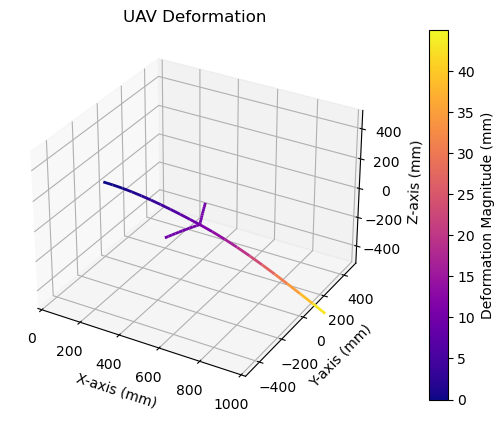

center_node
[0. 0. 0.]


In [19]:
arm_d1,arm_t,strut_d1,strut_t,strut_dist = Results.x

arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.add_force(np.array([0,0,-66]),"outer_node")
d1_fea.solve_fea()
d1_fea.solve_static()
d1_fea.solve_failure()

vis.drone_geometry_deformation(d1_fea,10,10)
print(d1_fea.beam_system.nodes[1].name)
print(d1_fea.beam_system.nodes[1].result_displacement)